# Luminosidad Estelar – Regresión Lineal Con Una Característica

En este cuaderno, modelamos la **luminosidad estelar** como una función de la masa estelar usando un modelo de regresión lineal con una característica.

## Objetivos del cuaderno

- Visualizar la relación entre masa y luminosidad de estrellas.
- Implementar un modelo de regresión lineal simple.
- Calcular el error del modelo usando Mean Squared Error (MSE).
- Analizar la función de costo.
- Implementar gradiente descendente paso a paso.

En regresión lineal simple, buscamos una relación de la forma:

$$\hat{L} = w \cdot M + b$$

Donde:
- $\hat{L}$ = Luminosidad predicha
- $M$ = Masa de la estrella (variable independiente)
- $w$ = Peso (pendiente)
- $b$ = Sesgo (intercepto)

---

## 1.  Visualización del Conjunto de Datos

En esta sección cargamos los datos de masa (M) y luminosidad (L) de estrellas y los visualizamos para entender la relación entre ambas variables.

### 1.1 Instalación de dependencias

Instalamos las librerías necesarias: NumPy para cálculos numéricos y Matplotlib para visualización.

In [1]:
# Instalamos las librerias requeridas
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

### 1.2 Carga de datos

Definimos dos arrays con los datos observados:
- **M**: Masa de las estrellas (en masas solares $M_\odot$)
- **L**: Luminosidad de las estrellas (en luminosidades solares $L_\odot$)

Los datos representan 10 estrellas con masas que van desde 0.6 hasta 2.4 masas solares.

In [3]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

### 1.3 Gráfica de Masa vs Luminosidad

Visualizamos la relación entre masa y luminosidad mediante un diagrama de dispersión. Esto nos permite observar el patrón de los datos antes de ajustar el modelo.

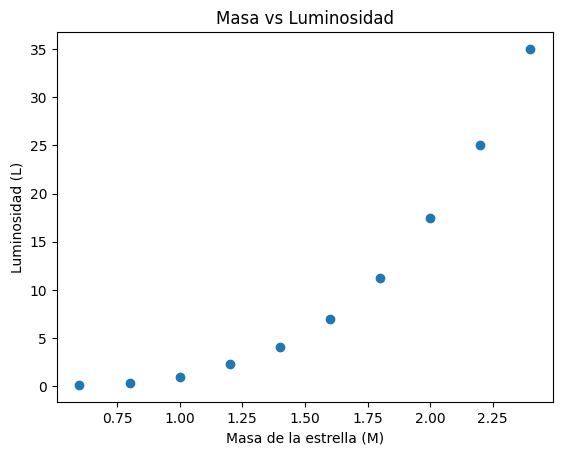

In [4]:
plt.figure()
plt.scatter(M, L)
plt.xlabel("Masa de la estrella (M)")
plt.ylabel("Luminosidad (L)")
plt.title("Masa vs Luminosidad")
plt.show()

#### Observaciones

Al ver la gráfica, se nota que cuando la masa aumenta, la luminosidad también aumenta.
Sin embargo, no crece de forma perfectamente recta, sino cada vez más rápido. Esto tiene sentido físicamente, ya que las estrellas más grandes suelen ser mucho más luminosas. La recta es solo una aproximación.

---

## 2. Modelo y Función de Error

### 2.1 Modelo de predicción

Definimos la hipótesis del modelo de regresión lineal:

$$\hat{L} = w \cdot M + b$$

Donde:
- $\hat{L}$ es la predicción de luminosidad
- $w$ es el peso (pendiente)
- $b$ es el sesgo (intercepto)

La función **predecir()** implementa esta ecuación.

In [5]:
# Función de predicción: L_hat = w * M + b
def predecir(M, w, b):
    return w * M + b

### 2.2 Función de costo (MSE)

Para medir qué tan buenas son nuestras predicciones, utilizamos el **Error Cuadrático Medio (MSE)**:

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2$$

Donde:
- $m$ = número de ejemplos de entrenamiento
- $\hat{L}^{(i)}$ = predicción para el ejemplo $i$
- $L^{(i)}$ = valor real para el ejemplo $i$
- El factor $\frac{1}{2}$ simplifica el cálculo de derivadas

In [6]:
# Función de error: Mean Squared Error (MSE)
def mse(L_real, L_pred):
    m = len(L_real)
    errores = L_pred - L_real
    costo = (1 / (2 * m)) * np.sum(errores ** 2)
    return costo

---

## 3. Superficie de Costo

### 3.1 Visualización de la función de costo

La función de costo $J(w, b)$ es una superficie en 3D donde:
- El eje X representa diferentes valores de $w$
- El eje Y representa diferentes valores de $b$  
- El eje Z representa el error (costo) para esa combinación

El objetivo del gradiente descendente es encontrar el punto mínimo de esta superficie.

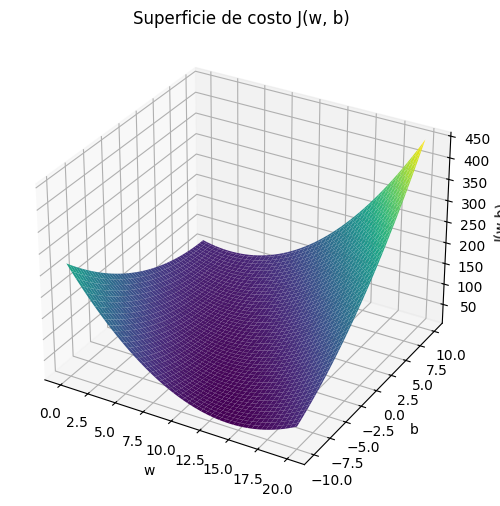

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

w_valores = np.linspace(0, 20, 100)
b_valores = np.linspace(-10, 10, 100)

W, B = np.meshgrid(w_valores, b_valores)
J = np.zeros_like(W)

# Calcular el error para cada combinación de w y b
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L_pred = predecir(M, W[i, j], B[i, j])
        J[i, j] = mse(L, L_pred)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.set_title("Superficie de costo J(w, b)")
plt.show()

#### Interpretación de la superficie

Cada punto de la gráfica representa un valor distinto de $w$ y $b$.
El punto donde el error es más bajo representa la mejor combinación de $w$ y $b$. La idea del gradiente descendente es moverse hacia ese mínimo.

La superficie tiene forma de "tazón" (convexa), lo que garantiza que existe un único mínimo global.

---

## 4. Gradientes

### 4.1 Derivadas parciales

Para actualizar los parámetros $w$ y $b$, necesitamos calcular las **derivadas parciales** de la función de costo:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)}) \cdot M^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})$$

Estas derivadas indican la **dirección** y **magnitud** del cambio necesario para reducir el error.

### 4.2 Implementación no vectorizada

La siguiente función calcula los gradientes usando un bucle **for**:

In [8]:
def calcular_gradientes_no_vectorizado(M, L, w, b):
    m = len(M)
    dj_dw = 0.0
    dj_db = 0.0
    
    for i in range(m):
        L_pred = w * M[i] + b
        error = L_pred - L[i]
        
        dj_dw += error * M[i]
        dj_db += error
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

---

## 5. Gradiente Descendente (No Vectorizado)

### 5.1 Algoritmo de optimización

El gradiente descendente actualiza los parámetros iterativamente usando las reglas:

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Donde $\alpha$ es la tasa de aprendizaje, que controla el tamaño del paso en cada iteración.

### 5.2 Implementación iterativa

La siguiente función implementa el algoritmo completo de gradiente descendente:

In [9]:
def gradiente_descendente(M, L, w_inicial, b_inicial, alpha, iteraciones):
    w = w_inicial
    b = b_inicial
    historial_iteraciones = []
    historial_error = []

    for i in range(iteraciones):
        dj_dw, dj_db = calcular_gradientes_no_vectorizado(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        error = mse(L, predecir(M, w, b))
        historial_iteraciones.append(i)
        historial_error.append(error)
        
        if i % max(1, (iteraciones // 10)) == 0:
            print(f"Iteración {i:4d}: w={w:7.4f}, b={b:7.4f}, costo={error:8.4f}")

    return w, b, historial_iteraciones, historial_error

---

## 6. Gradiente Descendente (Vectorizado)

### 6.1 Ventajas de la vectorización

La vectorización aprovecha operaciones matriciales para calcular todos los gradientes simultáneamente, eliminando bucles **for** y haciendo el código más eficiente.

Las mismas fórmulas se expresan de forma matricial:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \cdot (\hat{\mathbf{L}} - \mathbf{L})^T \cdot \mathbf{M}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \cdot \sum(\hat{\mathbf{L}} - \mathbf{L})$$

### 6.2 Implementación vectorizada de gradientes

In [10]:
def calcular_gradientes_vectorizado(M, L, w, b):
    m = len(M)

    L_pred = w * M + b
    error = L_pred - L

    dj_dw = (1 / m) * np.sum(error * M)  
    dj_db = (1 / m) * np.sum(error)    

    return dj_dw, dj_db

### 6.3 Algoritmo de gradiente descendente vectorizado

Implementación del algoritmo completo usando operaciones vectoriales de NumPy:

In [11]:
def gradiente_descendente_vectorizado(M, L, w_inicial, b_inicial, alpha, iteraciones):
    w = w_inicial
    b = b_inicial
    historial = []

    for i in range(iteraciones):
        dj_dw, dj_db = calcular_gradientes_vectorizado(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        costo = mse(L, predecir(M, w, b))
        historial.append((i, costo))

        if i % max(1, (iteraciones // 10)) == 0:
            print(f"Iteración {i:4d}: w={w:7.4f}, b={b:7.4f}, costo={costo:8.4f}")

    return w, b, historial

---

## 7. Convergencia

### 7.1 Entrenamiento del modelo

Ejecutamos el gradiente descendente con los siguientes hiperparámetros:
- $w_{inicial} = 0$
- $b_{inicial} = 0$
- $\alpha = 0.01$ (tasa de aprendizaje)
- 1000 iteraciones

In [12]:
w_final, b_final, historial = gradiente_descendente_vectorizado(
    M, L,
    w_inicial=0.0,
    b_inicial=0.0,
    alpha=0.01,
    iteraciones=1000
)

Iteración    0: w= 0.2152, b= 0.1036, costo=112.0896
Iteración  100: w= 6.8004, b= 1.5699, costo= 31.9704
Iteración  200: w= 7.9674, b=-0.0073, costo= 28.0913
Iteración  300: w= 8.8900, b=-1.5257, costo= 24.9336
Iteración  400: w= 9.7253, b=-2.9093, costo= 22.3208
Iteración  500: w=10.4849, b=-4.1680, costo= 20.1590
Iteración  600: w=11.1759, b=-5.3129, costo= 18.3703
Iteración  700: w=11.8044, b=-6.3543, costo= 16.8903
Iteración  800: w=12.3762, b=-7.3015, costo= 15.6658
Iteración  900: w=12.8962, b=-8.1632, costo= 14.6525


### 7.2 Gráfica de Pérdida vs Iteraciones

Visualizamos cómo el error $J(w, b)$ disminuye a lo largo del entrenamiento. Una curva descendente suave indica convergencia exitosa.

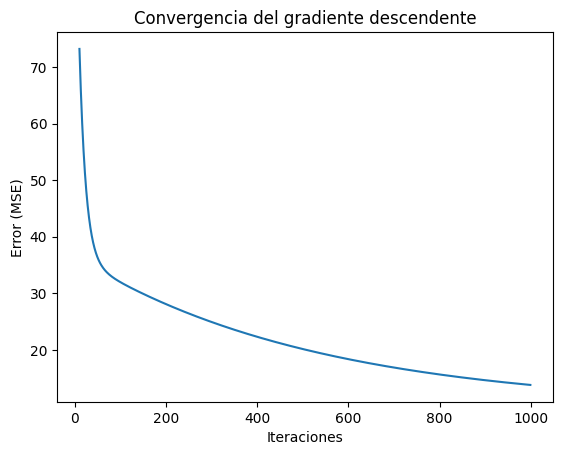

In [ ]:
iteraciones = [it for it, c in historial]
costos = [c for it, c in historial]

plt.figure()
plt.plot(iteraciones[10:], costos[10:])  
plt.xlabel("Iteraciones")
plt.ylabel("Error (MSE)")
plt.title("Convergencia del gradiente descendente")
plt.show()

#### Interpretación de la convergencia

La gráfica muestra que el error va disminuyendo con el paso de las iteraciones.
Esto indica que el algoritmo está convergiendo correctamente. El descenso es estable y no presenta saltos grandes, lo cual sugiere que el learning rate es adecuado.

Si el error oscila o aumenta, significa que $\alpha$ es muy grande. Si converge muy lento, $\alpha$ puede ser muy pequeño.

---

## 8. Experimentos

### 8.1 Comparación de diferentes valores de $\alpha$

Probamos diferentes valores de tasa de aprendizaje para observar su efecto en la convergencia:

| $\alpha$ | Comportamiento esperado |
|----------|------------------------|
| 0.001    | Convergencia lenta pero estable |
| 0.01     | Balance entre velocidad y estabilidad |
| 0.05     | Convergencia rápida, posible inestabilidad |

In [14]:
t_aprendizaje = [0.001, 0.01, 0.05]

for alpha in t_aprendizaje:
    w, b, errores = gradiente_descendente_vectorizado(
        M, L,
        w_inicial=0.0,
        b_inicial=0.0,
        alpha=alpha,
        iteraciones=1000
    )
    
    print("Tasa de aprendizaje:", alpha)
    print("w final:", w)
    print("b final:", b)
    print("Error final:", errores[-1])
    print("-" * 30)

Iteración    0: w= 0.0215, b= 0.0104, costo=117.1272
Iteración  100: w= 1.8528, b= 0.8539, costo= 76.1380
Iteración  200: w= 3.1775, b= 1.3941, costo= 55.5054
Iteración  300: w= 4.1445, b= 1.7209, costo= 45.0036
Iteración  400: w= 4.8589, b= 1.8976, costo= 39.5456
Iteración  500: w= 5.3949, b= 1.9691, costo= 36.6010
Iteración  600: w= 5.8048, b= 1.9668, costo= 34.9110
Iteración  700: w= 6.1253, b= 1.9130, costo= 33.8494
Iteración  800: w= 6.3826, b= 1.8233, costo= 33.1044
Iteración  900: w= 6.5950, b= 1.7088, costo= 32.5210
Tasa de aprendizaje: 0.001
w final: 6.7737785583999575
b final: 1.5787460037920253
Error final: (999, np.float64(32.02669669111435))
------------------------------
Iteración    0: w= 0.2152, b= 0.1036, costo=112.0896
Iteración  100: w= 6.8004, b= 1.5699, costo= 31.9704
Iteración  200: w= 7.9674, b=-0.0073, costo= 28.0913
Iteración  300: w= 8.8900, b=-1.5257, costo= 24.9336
Iteración  400: w= 9.7253, b=-2.9093, costo= 22.3208
Iteración  500: w=10.4849, b=-4.1680, cos

#### Análisis de resultados

| Tasa $\alpha$ | Observación |
|---------------|-------------|
| Pequeña (0.001) | El modelo aprende más lento, necesita más iteraciones |
| Intermedia (0.01) | El modelo converge de forma estable y eficiente |
| Grande (0.05) | El entrenamiento puede volverse inestable |

Elegir bien la tasa de aprendizaje es crucial. Un valor muy pequeño hace el entrenamiento lento, mientras que uno muy grande puede causar divergencia.

---

## 9. Gráfica Final del Ajuste

### 9.1 Visualización del modelo entrenado

Comparamos la línea de regresión ajustada con los datos reales para evaluar visualmente la calidad del modelo.

La ecuación del modelo final es:

$$\hat{L} = w_{final} \cdot M + b_{final}$$

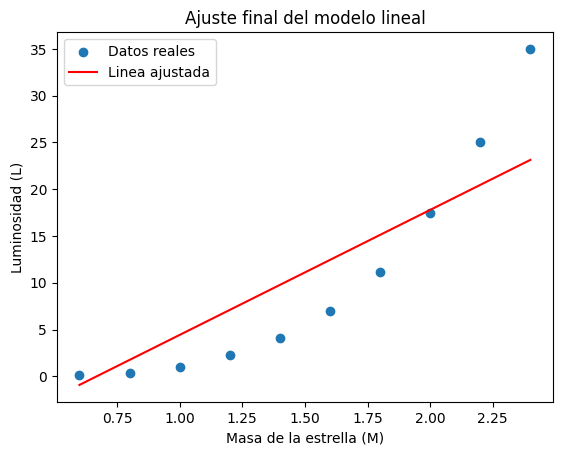

In [15]:
plt.figure()
plt.scatter(M, L, label="Datos reales")
L_ajustada = predecir(M, w_final, b_final)
plt.plot(M, L_ajustada, label="Linea ajustada", color="red")
plt.xlabel("Masa de la estrella (M)")
plt.ylabel("Luminosidad (L)")
plt.title("Ajuste final del modelo lineal")
plt.legend()
plt.show()

#### Evaluación del modelo

La recta se ajusta bien para valores pequeños de masa. Sin embargo, para masas grandes, el modelo se queda corto y subestima la luminosidad. 

**Análisis del error**:
- Para $M < 1.5$: El modelo predice razonablemente bien
- Para $M > 1.5$: El modelo subestima significativamente la luminosidad

---

## 10. Preguntas Conceptuales

### 10.1 ¿Cuál es el significado astrofísico de $w$?

El valor de $w$ indica cuánto aumenta la luminosidad cuando la masa de la estrella aumenta una unidad.
Es una forma simple de representar qué tan sensible es la luminosidad frente a la masa.

### 10.2 ¿Por qué un modelo lineal es limitado aquí?

En la realidad, la relación entre masa y luminosidad no es una línea recta.
La luminosidad crece mucho más rápido para estrellas grandes. 

**Relación empírica real (Ley de masa-luminosidad)**:

$$L \propto M^{\alpha}$$

Donde $\alpha \approx 3.5$ para estrellas de la secuencia principal.

Un modelo lineal $(\alpha = 1)$ no puede capturar este comportamiento exponencial, por eso comete errores significativos, especialmente en valores altos de masa.

---